In [1]:
import matplotlib.pyplot as plt  # For plotting results; optional
import numpy as np

from landlab import RasterModelGrid  # Grid utility
from landlab import imshow_grid  # For plotting results; optional
from landlab.components import Space  # SPACE model
from landlab.components import DepressionFinderAndRouter, FlowAccumulator


from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler

In [2]:
num_rows = 50
num_cols = 100
dxy = 50

mg = RasterModelGrid((num_rows, num_cols), xy_spacing=dxy)

# adding fields
z = mg.add_zeros('topographic__elevation', at='node', clobber=True)

soil = mg.add_zeros("soil__depth", at="node", clobber=True)

In [3]:
# set random roughness of terrain 
np.random.seed(42)

#define where the mountain front is - this can be changed if we want more area for the lowland 
front_y = 0.5 * mg.y_of_node.max()

#initial slopes 
basin_slope = 0.0005  #can change these
upland_slope = 0.03

# initiate drainage 
roughness = 0.05 * np.random.rand(mg.number_of_nodes)

# ID upland nodes 
upland = mg.y_of_node >= front_y

#create the distinct highland/lowland 
z[upland] += (50.0 + upland_slope * (mg.y_of_node[upland] - front_y))
z[:] += roughness 

In [4]:
#bedrock here means topography (to begin with) 
bedrock = mg.add_field("bedrock__elevation", z - soil, at="node", clobber=True)

In [5]:
# boundary conditons so that only the bottom is open 
mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=False, left_is_closed=True, right_is_closed=True, top_is_closed=True)

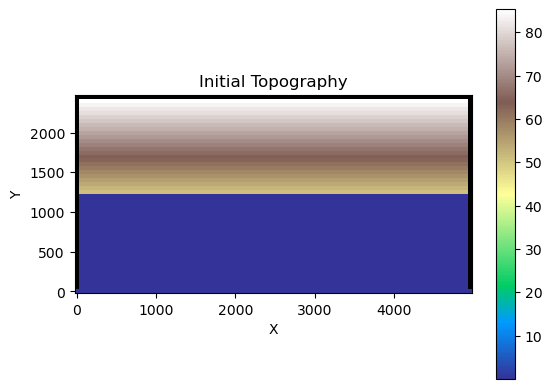

In [6]:
# Let's see our initial topographyyyy 
imshow_grid(mg, "topographic__elevation", cmap="terrain")
plt.title("Initial Topography")
plt.show()

In [7]:
#COMPONENTS!

# Instantiate flow router
fr = FlowAccumulator(mg, flow_director="FlowDirectorD8")

# Instantiate SPACE model with chosen parameters
sp = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=5.0,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [35]:
# What I think we need to do next: 
# 1. set the nodes that are > or = to front_y, and the ones that are less than front_y
# 2. set up uplift, timestep, total run time 
# 3. figure out how to track max sediment thickness in the basin 
# 4. Figure out rule for uplift in upland 
# 5. Figure out rules for calculating flow at different times (run_one_step) 
# 6. Erode transport and deposit the sediment 

#Experiments with time and uplift rate 


In [14]:
# 1. Define which nodes are upland and which are lowland 
upland_core_nodes = mg.core_nodes[mg.y_of_node[mg.core_nodes] >= front_y]

basin_core_nodes = np.where(mg.y_of_node < front_y)[0]

In [15]:
#2. Set up uplift, time step, and total run time - Able to change and mess with 
uplift_rate = 0.005 #m/yr
timestep = 100 #years
run_time = 5000 #years
count = 0 #set timestep count to zero 
n_steps = int(run_time / timestep) 

In [16]:
#3. Track max sed thickness 
model_time = np.zeros(n_steps)
max_basin_soil = np.zeros(n_steps)

In [17]:
#4. The loop that incorporates uplift and sed flux... 

for count in range(n_steps):
    
#HIGHLANDS
    # Uplift bedrock in the upland (this is causing erosion)
    uplift_amount = uplift_rate * timestep

    #Upland cores only 
    bedrock[upland_core_nodes] += uplift_amount
    z[upland_core_nodes] += uplift_amount

    # Recalculate flow on the uplifted/evolving surface
    fr.run_one_step()

#LOWLANDS
    
    # Erode, transport, and deposit sediment to lowland surface 
    sp.run_one_step(dt=timestep)

    # Save results
    model_time[count] = (count + 1) * timestep
    max_basin_soil[count] = soil[basin_core_nodes].max()

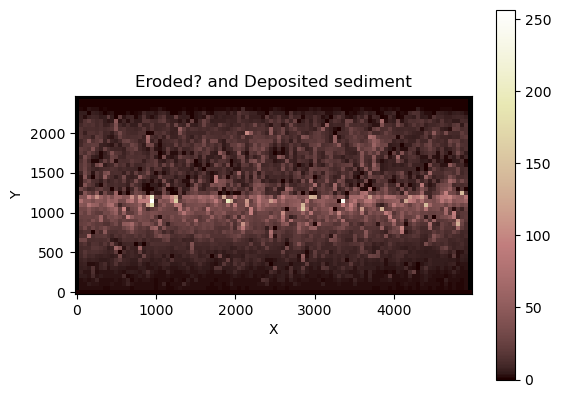

In [18]:
imshow_grid(
    mg,
    "soil__depth",
)

plt.title("Eroded? and Deposited sediment")
plt.show()

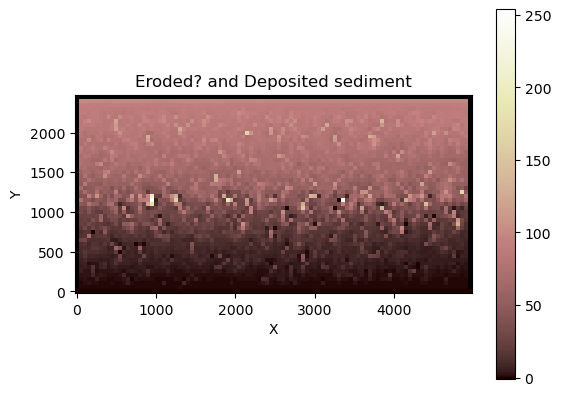

In [19]:
imshow_grid(
    mg,
    "topographic__elevation",
)

plt.title("Eroded? and Deposited sediment")
plt.show()